In [2]:
import sys
from dataset import RADIal
from encoder import ra_encoder
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
import cv2
sys.path.insert(0, '/home/skouff/RADIal/')
from DBReader.DBReader import SyncReader
from DBReader.DBReader.SensorsReaders import CANDecoder
from SignalProcessing import RadarSignalProcessing


import numpy as np
import os

In [4]:
from dataloader import CreateDataLoaders


config = {
    "data_mode":"Custom_RD",
    "dataset": {
        "root_dir": "/Benson_DATA3/Public/RADIal/ready_to_use/RADIal/",
        "geometry":{
            "ranges": [512,896,1],
            "resolution": [0.201171875,0.2],
            "size": 3
        },
        "statistics":{
            "input_mean":[-2.62437651e-03, -2.13345470e-01,  1.87890028e-02, -1.44272549e+00,
               -3.76185047e-01,  1.35935890e+00, -2.29865852e-01,  1.22432935e-01,
                1.73593029e+00, -6.53456097e-01,  3.79762385e-01,  5.55212892e+00,
                7.74623837e-01, -1.55886042e+00, -7.24735683e-01,  1.51824262e+00,
               -3.71890112e-01, -8.83323401e-02, -1.61938504e-01,  1.09838836e+00,
                9.99290420e-01, -1.04952120e+00,  1.99716390e+00,  9.28686109e-01,
                1.89906800e+00, -2.37724935e-01,  1.99996778e+00,  7.77374669e-01,
                1.32391419e+00,  1.18174904e+00, -6.96956490e-01,  4.42879647e-01],
            "input_std":[20775.32866954, 23085.38586781, 23017.53041219, 14548.55197203,
                 32133.36398373, 28838.72008902, 27195.74436859, 33103.59882674,
                 32181.40955515, 35022.0350309,  31259.08457192, 36684.42768439,
                 33552.77541718, 25958.69536146, 29532.48663633, 32646.76200793,
                 20728.21451047, 23160.77110769, 23068.97650426, 14915.83084849,
                 32149.49991635, 28958.47224165, 27210.72879388, 33005.5213712,
                 31905.82548318, 35124.76263393, 31258.3364471,  31085.84958294,
                 33628.4113574,  25950.13585943, 29445.21585193, 32885.56853172],
            "reg_mean":[0.4048094369863972,0.3997392847799934],
            "reg_std":[0.6968599580482511,0.6942950877813826]
        },
    },
    "dataloader": {
            "mode":"sequence",
            "split":[0.7,0.15,0.15],
            "train": {
                "batch_size": 4,
                "num_workers": 1
            },
            "val": {
                "batch_size": 4,
                "num_workers": 1
            },
            "test": {
                "batch_size": 1,
                "num_workers": 1
            }
        },
        "seed":3
}
enc = ra_encoder(geometry = config['dataset']['geometry'],
                        statistics = config['dataset']['statistics'],
                        regression_layer = 2)

dataset = RADIal(root_dir = config['dataset']['root_dir'],
                        statistics= config['dataset']['statistics'],
                        encoder=enc.encode,
                        difficult=True,perform_FFT=config['data_mode'])
root_folder = '/Benson_DATA3/Public/RADIal/raw_sequences/RECORD@2020-11-22_12.45.05'
db = SyncReader(root_folder,tolerance=20000, silent=True)

RSP = RadarSignalProcessing('/home/skouff/RADIal/SignalProcessing/CalibrationTable.npy',method='RA',device='cuda',lib='CuPy')
sample = db.GetSensorData(18)
ra= RSP.run(sample['radar_ch0']['data'],sample['radar_ch1']['data'],sample['radar_ch2']['data'],sample['radar_ch3']['data'])

# Find the corresponding item in the dataset
train_loader, val_loader, test_loader = CreateDataLoaders(dataset,config['dataloader'],config['seed'])

for data in test_loader:
    radar_FFT = data[0]
    segmap = data[1]
    out_label = data[2]
    box_labels = data[3]
    image = data[4]
    break

frame = cv2.cvtColor(sample['camera']['data'], cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(frame)
ax.axis('off')
box = box_labels
for box in box_labels:
    if box[0] == -1 : 
        break
    rect = Rectangle(box[6:8],(box[8]-box[6]),(box[9]-box[7]),linewidth=3, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
ax.axis('off')

CuPy on GPU will be used to execute the processing


KeyboardInterrupt: 

/home/skouff/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


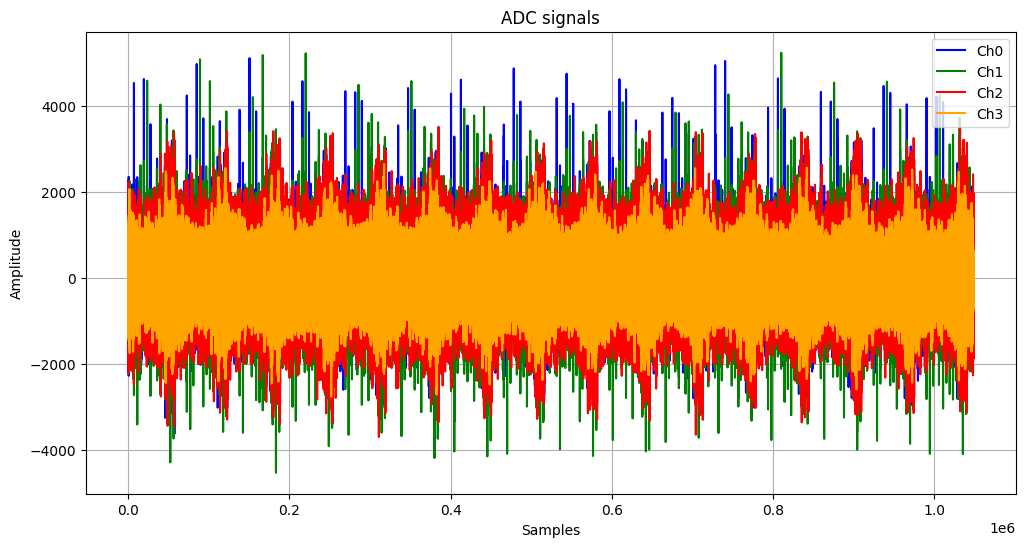

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(sample['radar_ch0']['data'], label='Ch0', color='blue')
plt.plot(sample['radar_ch1']['data'], label='Ch1', color='green')
plt.plot(sample['radar_ch2']['data'], label='Ch2', color='red')
plt.plot(sample['radar_ch3']['data'], label='Ch3', color='orange')
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("ADC signals")
plt.grid(True)
plt.legend()
plt.show()

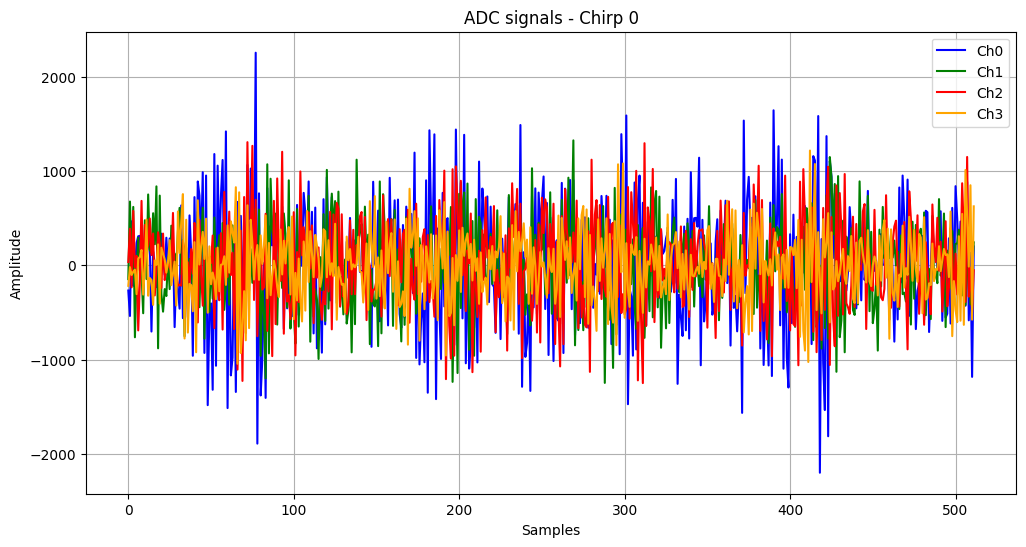

In [ ]:
samples_per_chirp = 512
chirp_idx = 0
start = chirp_idx * samples_per_chirp
end = start + samples_per_chirp

plt.figure(figsize=(12, 6))
plt.plot(sample['radar_ch0']['data'][start:end], label='Ch0', color='blue')
plt.plot(sample['radar_ch1']['data'][start:end], label='Ch1', color='green')
plt.plot(sample['radar_ch2']['data'][start:end], label='Ch2', color='red')
plt.plot(sample['radar_ch3']['data'][start:end], label='Ch3', color='orange')
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title(f"ADC signals - Chirp {chirp_idx}")
plt.grid(True)
plt.legend()
plt.show()

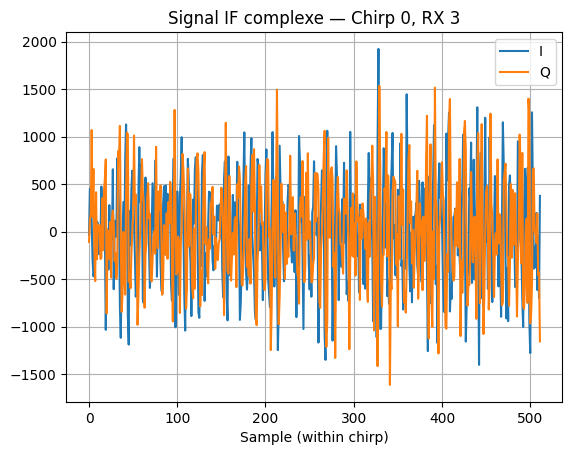

In [ ]:
# Décoder un seul canal, chirp 0
adc0 = sample['radar_ch0']['data']  # signal brut du canal 0
I = adc0[0::2]  # partie réelle
Q = adc0[1::2]  # partie imaginaire

# Reshape : (512 samples, 256 chirps, 4 RX)
frame = np.reshape(I + 1j*Q, (512, 4, 256), order='F').transpose((0, 2, 1))

# Plotter le chirp 0, RX 0
plt.plot(np.real(frame[:, 0, 3]), label='I')
plt.plot(np.imag(frame[:, 0, 3]), label='Q')
plt.xlabel("Sample (within chirp)")
plt.title("Signal IF complexe — Chirp 0, RX 3")
plt.legend()
plt.grid(True)
plt.show()

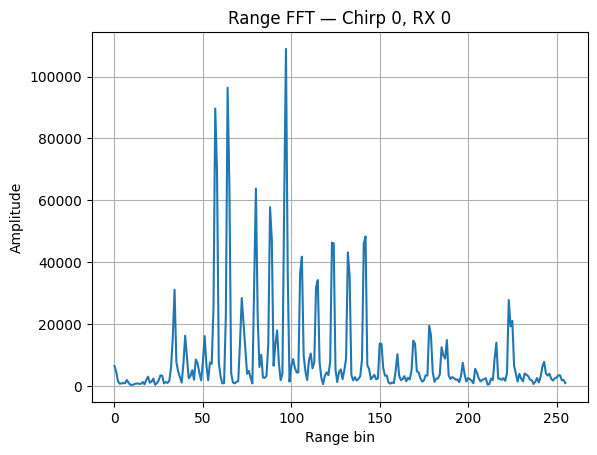

In [ ]:
from numpy.fft import fft, fftfreq
import numpy as np

chirp = frame[:, 0, 0]  # 512 samples, complexe

# Fenêtre de Hanning (comme dans le code RADIal)
window = 0.54 - 0.46 * np.cos(2 * np.pi * np.arange(512) / 511)
chirp_windowed = chirp * window

# Range FFT
range_fft = np.abs(fft(chirp_windowed))[:256]  # moitié utile

plt.plot(range_fft)
plt.xlabel("Range bin")
plt.ylabel("Amplitude")
plt.title("Range FFT — Chirp 0, RX 0")
plt.grid(True)
plt.show()

Angle du pic : 64.8°


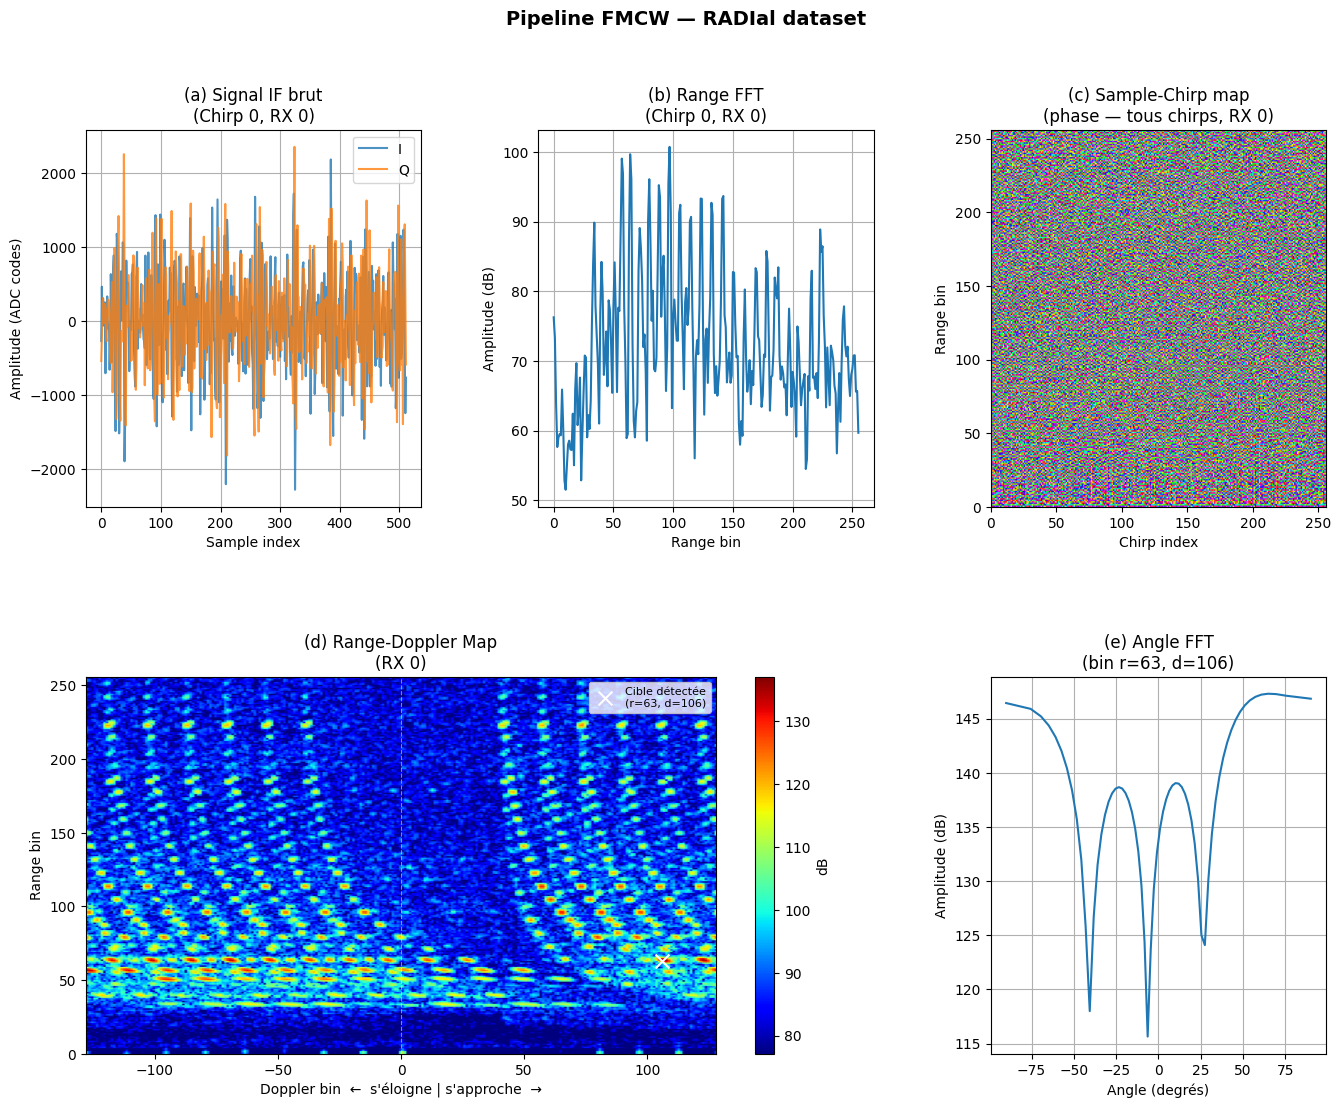

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Paramètres RADIal ──────────────────────────────────────────────
N_range   = 512
N_chirps  = 256
N_rx      = 4   # par chip (adc0)

# ── Décodage ──────────────────────────────────────────────────────
I = adc0[0::2]; Q = adc0[1::2]
frame = np.reshape(I + 1j*Q, (N_range, 4, N_chirps), order='F').transpose((0,2,1))
# shape: (512, 256, 4) = (range_samples, chirps, rx)

# ── Fenêtres de Hanning ───────────────────────────────────────────
win_r = 0.54 - 0.46*np.cos(2*np.pi*np.arange(N_range)  / (N_range-1))
win_d = 0.54 - 0.46*np.cos(2*np.pi*np.arange(N_chirps) / (N_chirps-1))

# ══════════════════════════════════════════════════════════════════
# ÉTAPE 1 — Signal brut IF (un chirp)
# ══════════════════════════════════════════════════════════════════
chirp0_rx0 = frame[:, 0, 0]   # chirp 0, RX 0

# ══════════════════════════════════════════════════════════════════
# ÉTAPE 2 — Range FFT  (sur tous les chirps, RX 0)
# ══════════════════════════════════════════════════════════════════
data = frame[:, :, 0]                          # (512, 256)
data_win_r = data * win_r[:, None]             # fenêtre range
range_fft  = np.fft.fft(data_win_r, axis=0)   # FFT sur axis range
range_fft  = range_fft[:N_range//2, :]        # moitié utile → (256, 256)

# ══════════════════════════════════════════════════════════════════
# ÉTAPE 3 — Range-Doppler Map  (Doppler FFT sur range_fft)
# ══════════════════════════════════════════════════════════════════
rd_map  = np.fft.fft(range_fft * win_d[None,:], axis=1)  # FFT sur axis chirp
rd_map  = np.fft.fftshift(rd_map, axes=1)                 # centrer Doppler=0

# ══════════════════════════════════════════════════════════════════
# ÉTAPE 4 — Angle FFT  (sur les 4 RX pour un bin Range-Doppler donné)
# ══════════════════════════════════════════════════════════════════
# Trouver le bin (range, doppler) avec le max d'énergie = cible dominante
rd_power = np.abs(rd_map)
r_peak, d_peak = np.unravel_index(np.argmax(rd_power), rd_power.shape)

# Extraire le phaseur à ce bin pour chaque RX
phasors = np.zeros(N_rx, dtype=complex)
for rx in range(N_rx):
    data_rx  = frame[:, :, rx] * win_r[:, None]
    rfft_rx  = np.fft.fft(data_rx, axis=0)[:N_range//2, :]
    rdfft_rx = np.fft.fftshift(np.fft.fft(rfft_rx * win_d[None,:], axis=1), axes=1)
    phasors[rx] = rdfft_rx[r_peak, d_peak]

# Zero-padding pour une meilleure résolution angulaire
N_angle  = 64
angle_fft = np.fft.fftshift(np.fft.fft(phasors, n=N_angle))
angle_bins = np.arcsin(np.linspace(-1, 1, N_angle)) * 180/np.pi  # en degrés

# ══════════════════════════════════════════════════════════════════
# FIGURE COMPLÈTE
# ══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── (a) Signal IF brut ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(np.real(chirp0_rx0), label='I', alpha=0.8)
ax1.plot(np.imag(chirp0_rx0), label='Q', alpha=0.8)
ax1.set_xlabel("Sample index")
ax1.set_ylabel("Amplitude (ADC codes)")
ax1.set_title("(a) Signal IF brut\n(Chirp 0, RX 0)")
ax1.legend(); ax1.grid(True)

# ── (b) Spectre Range FFT (chirp 0) ───────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
range_profile = 20*np.log10(np.abs(range_fft[:, 0]) + 1e-6)
ax2.plot(range_profile)
ax2.set_xlabel("Range bin")
ax2.set_ylabel("Amplitude (dB)")
ax2.set_title("(b) Range FFT\n(Chirp 0, RX 0)")
ax2.grid(True)

# ── (c) Sample-Chirp map (phase) ──────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(np.angle(range_fft), aspect='auto', origin='lower',
           extent=[0, N_chirps, 0, N_range//2], cmap='hsv')
ax3.set_xlabel("Chirp index")
ax3.set_ylabel("Range bin")
ax3.set_title("(c) Sample-Chirp map\n(phase — tous chirps, RX 0)")

# ── (d) Range-Doppler Map ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
rd_db = 20*np.log10(np.abs(rd_map) + 1e-6)
im = ax4.imshow(rd_db, aspect='auto', origin='lower',
                extent=[-N_chirps//2, N_chirps//2, 0, N_range//2],
                cmap='jet', vmin=rd_db.max()-60)
plt.colorbar(im, ax=ax4, label='dB')
ax4.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax4.scatter(d_peak - N_chirps//2, r_peak, c='white', marker='x', s=100,
            label=f'Cible détectée\n(r={r_peak}, d={d_peak-N_chirps//2})')
ax4.set_xlabel("Doppler bin  ←  s'éloigne | s'approche  →")
ax4.set_ylabel("Range bin")
ax4.set_title("(d) Range-Doppler Map\n(RX 0)")
ax4.legend(loc='upper right', fontsize=8)

# ── (e) Angle FFT ─────────────────────────────────────────────────
peak_idx   = np.argmax(np.abs(angle_fft))
peak_angle = angle_bins[peak_idx]

print(f"Angle du pic : {peak_angle:.1f}°")
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(angle_bins, 20*np.log10(np.abs(angle_fft) + 1e-6))
ax5.set_xlabel("Angle (degrés)")
ax5.set_ylabel("Amplitude (dB)")
ax5.set_title(f"(e) Angle FFT\n(bin r={r_peak}, d={d_peak-N_chirps//2})")
ax5.grid(True)

plt.suptitle("Pipeline FMCW — RADIal dataset", fontsize=14, fontweight='bold')
plt.show()

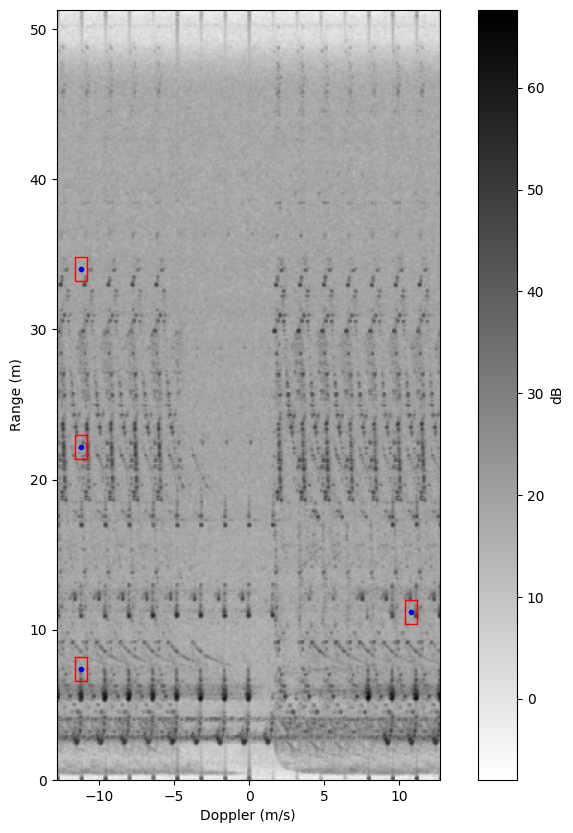

In [ ]:
import matplotlib.patches as patches
N = 256
NR = 512
delta_v = 0.1
Vmax = delta_v * (N // 2)
delta_r = 0.201171875
velocity_bins = np.arange(N) * delta_v - Vmax
range_bins = np.arange(N) * delta_r

radar_FFT = radar_FFT[...,::2]+1j*radar_FFT[...,1::2]
power_spectrum = np.sum(np.abs(radar_FFT),axis=2)
power_db = 20 * np.log10(power_spectrum + 1e-10) 
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(power_db, origin='lower', extent=[velocity_bins[0], velocity_bins[-1], range_bins[0], range_bins[-1]], cmap='gray_r')
fig.colorbar(im, label='dB')
half_doppler = 4 * delta_v      # en m/s
half_range   = 4 * delta_r      # en mètres

for box in box_labels:
    if box[0] == -1:
        break
    r_m  = box[0]                              # range en mètres
    d_ms = (box[2] - N // 2) * delta_v        # doppler bin → m/s

    rect = patches.Rectangle(
        (d_ms - half_doppler, r_m - half_range),
        2 * half_doppler, 2 * half_range,
        linewidth=1, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)
    ax.plot(d_ms, r_m, 'bo', markersize=3)
ax.set_xlabel('Doppler (m/s)')
ax.set_ylabel('Range (m)')
plt.show()

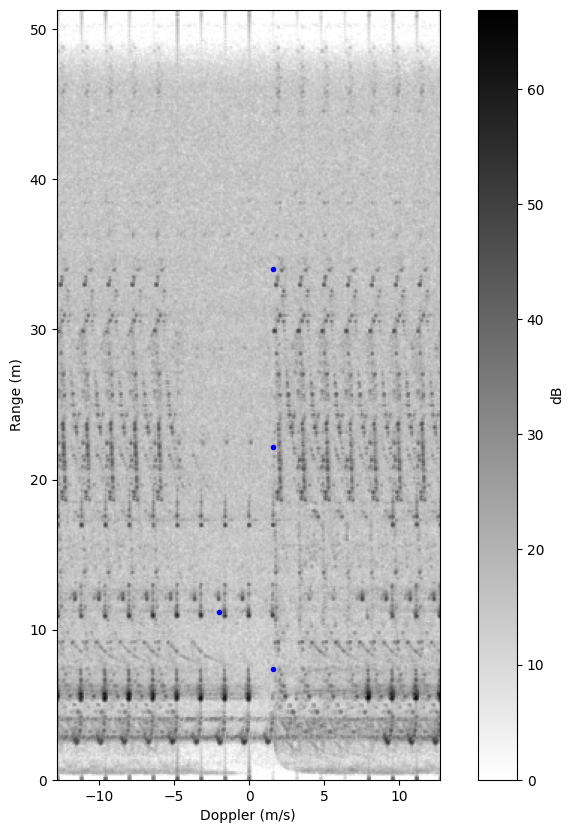

In [ ]:
import matplotlib.patches as patches
N = 256
delta_v = 0.1
Vmax = delta_v * (N // 2)
delta_r = 0.201171875
velocity_bins = np.arange(N) * delta_v - Vmax
range_bins = np.arange(N) * delta_r

radar_FFT = radar_FFT[...,::2]+1j*radar_FFT[...,1::2]
power_spectrum = np.sum(np.abs(radar_FFT),axis=2)
power_db = 20 * np.log10(power_spectrum + 1e-10) 
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(power_db, origin='lower', extent=[velocity_bins[0], velocity_bins[-1], range_bins[0], range_bins[-1]], cmap='gray_r', vmin=0, vmax=power_db.max())
fig.colorbar(im, label='dB')
half_doppler = 4 * delta_v      # en m/s
half_range   = 4 * delta_r      # en mètres

for box in box_labels:
    if box[0] == -1:
        break
    r_m  = box[0]                              # range en mètres
    shifted_bin = (int(box[2]) + 128) % 256
    d_ms = velocity_bins[shifted_bin]

    ax.plot(d_ms, r_m, 'bo', markersize=3)
ax.set_xlabel('Doppler (m/s)')
ax.set_ylabel('Range (m)')
plt.show()

[]

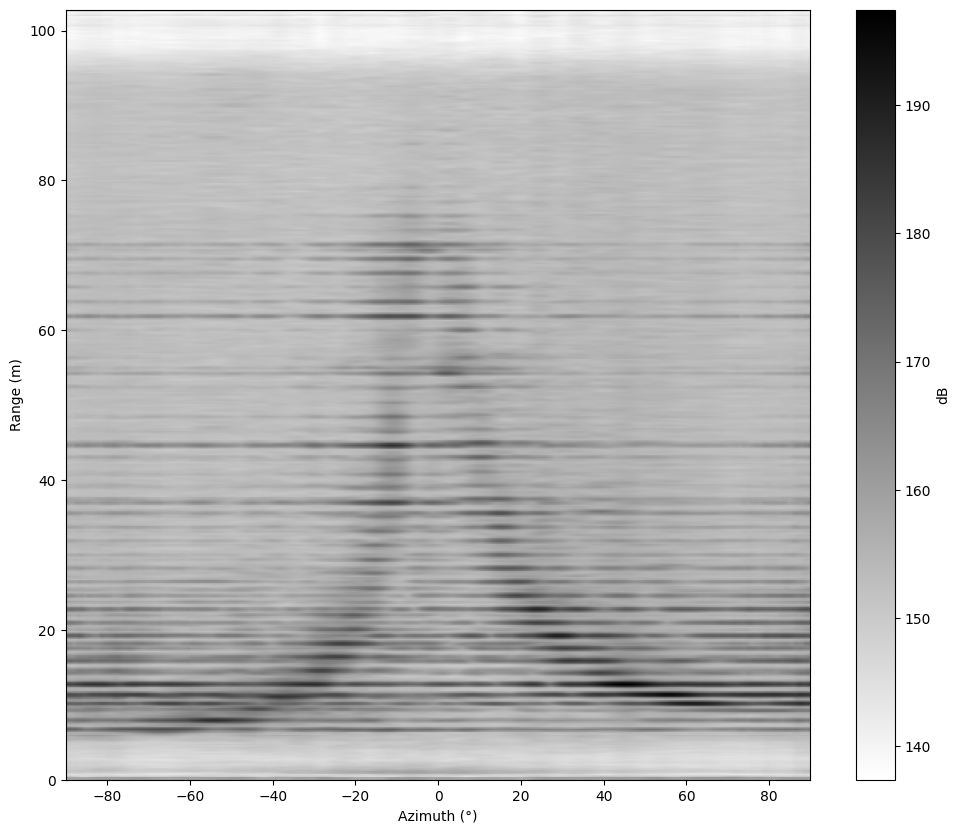

In [ ]:
N = ra.shape[1]  # azimuth bins
M = ra.shape[0]  # range bins
max_range = 103
az_res = 180 / N  # degrés par bin

azimuth_bins = np.arange(N) * az_res - 90   # -90 à +90°
range_bins   = np.arange(M) * (max_range / M)

ra_db = 20 * np.log10(ra + 1e-10)
fig, ax = plt.subplots(figsize=(12, 10))
im =ax.imshow(
    ra_db, origin='lower', aspect='auto', cmap='gray_r',
    extent=[azimuth_bins[0], azimuth_bins[-1], range_bins[0], range_bins[-1]],
)
fig.colorbar(im, label='dB')
max_range = 103 
half_azimuth_bins = 8
half_range_bins = 8
for box in box_labels:
    if(box[0]==-1):
        break # -1 means no object
    azimuth_deg = box[1]  # radar_A_deg
    range_m = box[0] 
    azimuth_bin = int((azimuth_deg + 90) * (N / 180))
    range_bin = int(range_m * (M / max_range))

    x_corner = azimuth_bin - half_azimuth_bins
    y_corner = range_bin - half_range_bins

    # rect = patches.Rectangle((x_corner, y_corner), 2*half_azimuth_bins, 2*half_range_bins, linewidth=1, edgecolor='r', facecolor='none', zorder=3)
    # ax.add_patch(rect)
    # ax.plot(azimuth_bin, range_bin, 'bo', zorder=2)
ax.set_xlabel('Azimuth (°)')
ax.set_ylabel('Range (m)')
plt.plot()

CPU will be used to execute the processing


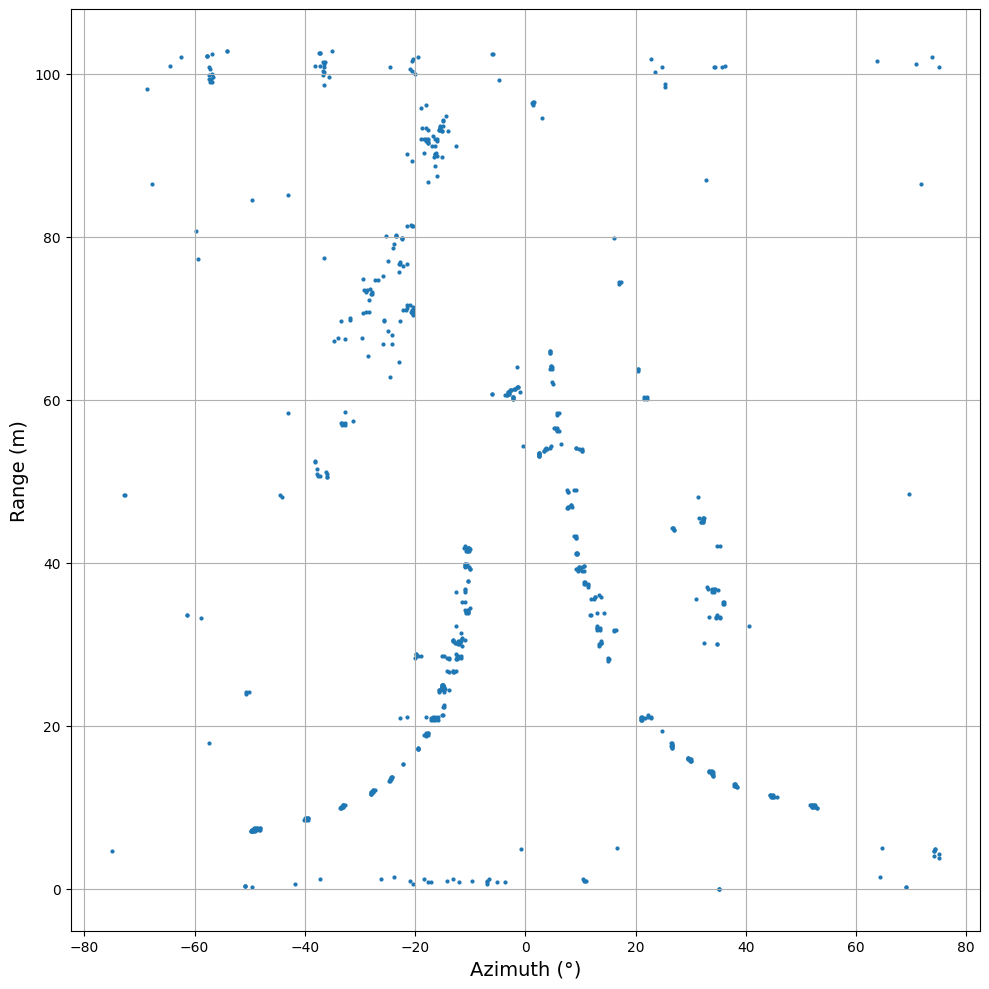

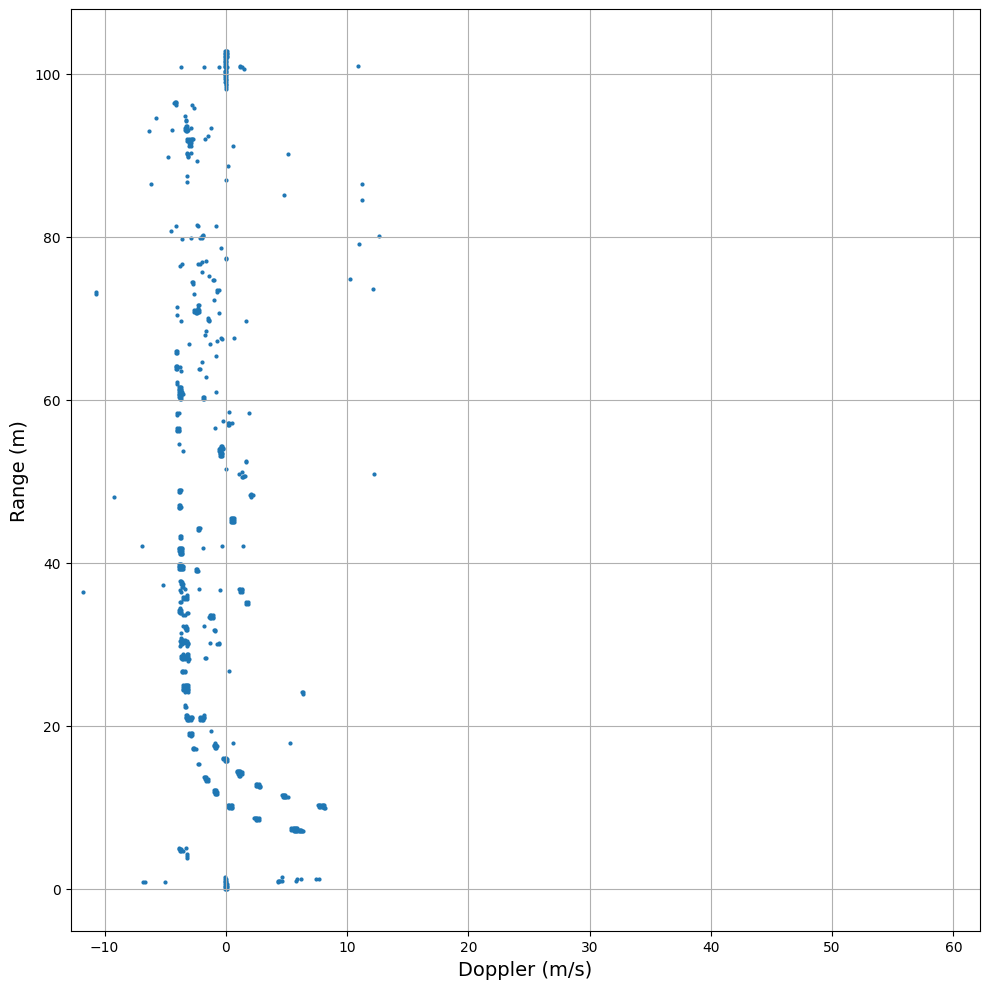

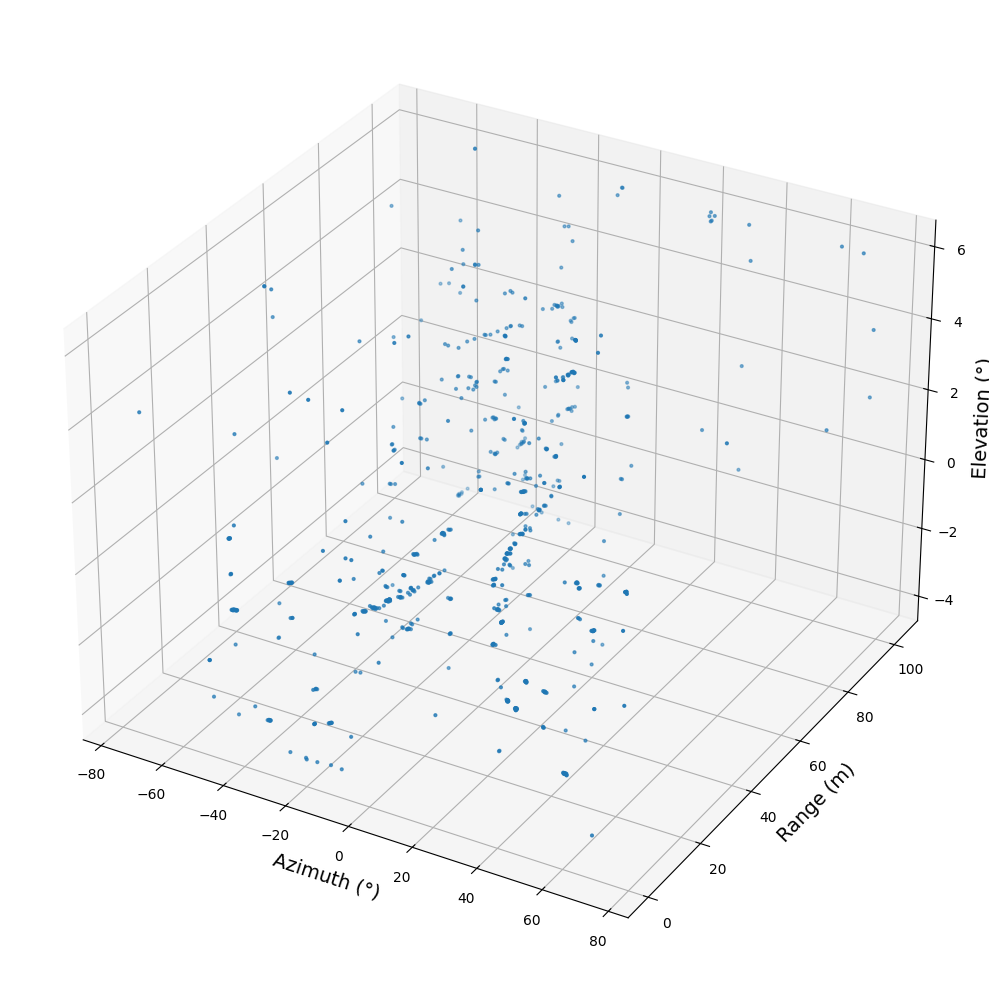

In [ ]:
RSP = RadarSignalProcessing('/home/skouff/RADIal/SignalProcessing/CalibrationTable.npy',method='PC')
sample = db.GetSensorData(26)
pc= RSP.run(sample['radar_ch0']['data'],sample['radar_ch1']['data'],sample['radar_ch2']['data'],sample['radar_ch3']['data'])
# PC = [Range,Doppler,Azimuth,Elevation]
range_    = pc[:, 0]       # mètres
az_rad    = pc[:, 2]       # radians
el_rad    = pc[:, 3]       # radians

az_deg = np.rad2deg(az_rad)
el_deg = np.rad2deg(el_rad)

decoder = CANDecoder("/home/skouff/RADIal/DBReader/examples/can_database.dbc")
odometry = db.GetMostRecentOdometry(decoder,sample['camera']['timestamp'])
velocity_bins = np.arange(N) * delta_v - Vmax
speed = odometry[2]  / 3.6
shifted_bins = ((pc[:, 1].astype(int) + 128) % 256).astype(int)
doppler = velocity_bins[shifted_bins]  # doppler en m/s
# doppler = doppler + speed


# --- Range-Azimuth ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(az_deg, range_, s=4)
ax.set_xlabel('Azimuth (°)', fontsize=14)
ax.set_ylabel('Range (m)', fontsize=14)
ax.grid(True)
plt.tight_layout(); plt.show()

# --- Range-Doppler ---
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(doppler, range_, s=4)
ax.set_xlabel('Doppler (m/s)', fontsize=14)
ax.set_ylabel('Range (m)', fontsize=14)
ax.set_xlim(velocity_bins[0], velocity_bins[-1])
ax.grid(True)
plt.tight_layout(); plt.show()

# --- 3D ---
fig3d = plt.figure(figsize=(10, 10))
ax3d = fig3d.add_subplot(111, projection='3d')
sc = ax3d.scatter(az_deg, range_, el_deg, s=4)
ax3d.set_xlabel('Azimuth (°)', fontsize=14)
ax3d.set_ylabel('Range (m)', fontsize=14)
ax3d.set_zlabel('Elevation (°)', fontsize=14)
plt.tight_layout(); plt.show()
